In [1]:
import matplotlib
import matplotlib.pyplot as plt
#from collections import OrderedDict
import seaborn as sns

import numpy as np
import os
import scipy
import pickle

from neurolib.models.aln import ALNModel
import neurolib.utils.functions as func
from neurolib.utils import costFunctions as cost
from neurolib.utils import plotFunctions as plotFunc

# a nice color map
#sns.set()
#cmap = plt.get_cmap('plasma')
plt.rcParams['image.cmap'] = 'plasma'
cpalette = sns.color_palette('plasma')
np.set_printoptions(precision=4)

#matplotlib.style.use('classic')

font = {
    'family' : 'sans',
    'weight' : 'normal',
    'size'   : 14
       }

matplotlib.rc('font', **font)
matplotlib.rc('xtick', labelsize=16) 
matplotlib.rc('ytick', labelsize=16) 
matplotlib.rc('grid', c='0.5', ls='-', lw=0.5)  # solid gray grid lines
matplotlib.rc('savefig', dpi=300)       # higher res outputs
#print (matplotlib.rcParams)
    
# This will reload all imports as soon as the code changes
%load_ext autoreload
%autoreload 2 

path = os.path.join(os.getcwd(), "plots")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Oscillations and stable up and down

In [2]:
aln = ALNModel()
N = aln.params.N
aln.params.dt = .1

aln.params.mufe_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.mufi_init = 0 * np.random.uniform(0, 1, (N,))  # mV/ms
aln.params.seem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.seev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.seiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siim_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siem_init = 0. * np.random.uniform(0, 1, (N,))
aln.params.siiv_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.siev_init = 0.0 * np.random.uniform(0, 1, (N,))
aln.params.rates_exc_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.rates_inh_init = 0.0 * np.random.uniform(0, 1, (N, 1))
aln.params.IA_init = 0.0 * np.random.uniform(0, 1, (N, 1))  # pA

aln.params.sigma_ou = 0.
aln.params.mue_ou = np.array( [0.] )
aln.params.mui_ou = np.array( [0.] )

state_vars = aln.state_vars
init_vars = aln.init_vars

def setinit(init_vars_):
    for iv in range(len(init_vars)):
        for sv in range(len(state_vars)):
            if state_vars[sv] in init_vars[iv]:
                #print("set init vars ", )
                if aln.params[init_vars[iv]].ndim == 2:
                    aln.params[init_vars[iv]][0,:] = init_vars_[sv]
                else:
                    aln.params[init_vars[iv]][0] = init_vars_[sv]
                    
def set_params_slow():
    # external currents for aE limit cycle (slow)
    aln.params.ext_exc_current = 4.
    aln.params.ext_inh_current = 2.
    
def set_params_fast():
    # external currents for EI limit cycle (fast)
    aln.params.ext_exc_current = 2.5
    aln.params.ext_inh_current = 0.
    
def set_params_up():
    # external currents for up state
    aln.params.ext_exc_current = 5.
    aln.params.ext_inh_current = 1.
    
def set_params_down():
    # external currents for up state
    aln.params.ext_exc_current = 2.
    aln.params.ext_inh_current = 3.

In [3]:
aln.params.duration = 800.
aln.params.mue_ext_mean = 0.0
aln.params.mui_ext_mean = 0.0

control0 = aln.getZeroControl()

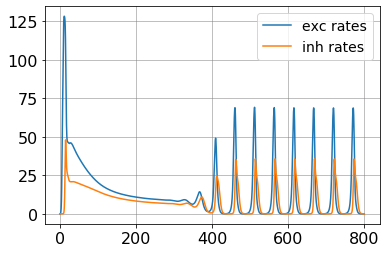

In [4]:
set_params_fast()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

fast_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        fast_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        fast_osc_init[i] = aln.state[state_vars[i]][0,-1]

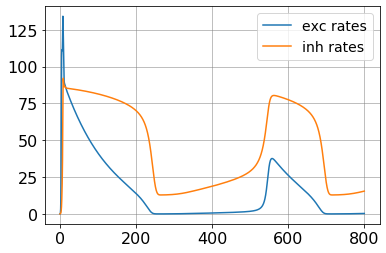

In [5]:
set_params_slow()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

slow_osc_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        slow_osc_init[i] = aln.state[state_vars[i]][0]
    else:
        slow_osc_init[i] = aln.state[state_vars[i]][0,-1]

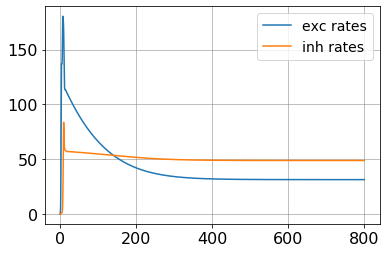

[31.3076 48.768 ]


In [6]:
set_params_up()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

up_rates = np.zeros((2))
up_rates[0] = aln.rates_exc[0,-1]
up_rates[1] = aln.rates_inh[0,-1]

print(up_rates)

up_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        up_init[i] = aln.state[state_vars[i]][0]
    else:
        up_init[i] = aln.state[state_vars[i]][0,-1]

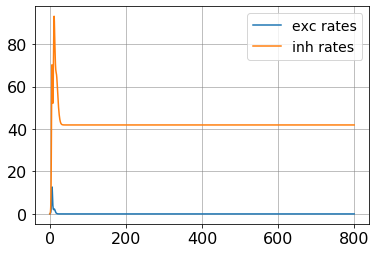

[4.4580e-10 4.1918e+01]


In [7]:
set_params_down()
aln.run(control = control0)

plt.plot(aln.t, aln.rates_exc[0,:], label="exc rates")
plt.plot(aln.t, aln.rates_inh[0,:], label="inh rates")
plt.legend()
plt.show()

down_rates = np.zeros((2))
down_rates[0] = aln.rates_exc[0,-1]
down_rates[1] = aln.rates_inh[0,-1]

print(down_rates)

down_init = np.zeros(( len(state_vars) ))
for i in range(len(state_vars)):
    if aln.state[state_vars[i]].size == 1:
        down_init[i] = aln.state[state_vars[i]][0]
    else:
        down_init[i] = aln.state[state_vars[i]][0,-1]

In [8]:
def setmaxmincontrol(cntrl_vars):
    max_cntrl = np.zeros(( 4 ))
    min_cntrl = np.zeros(( 4 ))
    if cntrl_vars == [0]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
    elif cntrl_vars == [1]:
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
    elif cntrl_vars == [2]:
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
    elif cntrl_vars == [0,1]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
    elif cntrl_vars == [0,2]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
    elif cntrl_vars == [1,2]:
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
    elif cntrl_vars == [0,1,2]:
        max_cntrl[0] = 5.
        min_cntrl[0] = - 5.
        max_cntrl[1] = 5.
        min_cntrl[1] = - 5.
        max_cntrl[2] = 0.15
        min_cntrl[2] = 0.
            
    return max_cntrl, min_cntrl     

def findclosestindex(osc_rate, stable_rate, startind):
    mindiff = 1000.
    minind = -1
    for t in range(startind, len(osc_rate)):
        diff = np.abs(osc_rate[t] - stable_rate)
        if diff < mindiff:
            mindiff = diff
            minind = t
    return mindiff, minind
        
    
def findclosestindex_2d(osc_rate, stable_rate, startind):
    mindiff = 1000.
    minind = -1
    for t in range(startind, len(osc_rate[0,:])):
        diff = np.abs(osc_rate[0,t] - stable_rate[0]) + np.abs(osc_rate[1,t] - stable_rate[1])
        if diff < mindiff:
            mindiff = diff
            minind = t
    return mindiff, minind

def setpredur(prec_vars):
    if prec_vars == [0]:
        dur_pre = dur_pre_e
    elif prec_vars == [1]:
        dur_pre = dur_pre_i
    else:
        dur_pre = dur_pre_2d
    n_pre = int(np.around(dur_pre/aln.params.dt + 1.,1))
    
    return dur_pre, n_pre

def settarget(initVars_, dur_, dur_pre_, n_pre_):
    aln.params.duration = dur_

    # set low state rates as target
    target = aln.getZeroTarget()
    target[:,0,n_dt_maxDelay:] = target_rates[0]
    target[:,1,n_dt_maxDelay:] = target_rates[1]

    aln.params.duration = dur_ + dur_pre_
    setinit(initVars_)
    aln.run(control=aln.getZeroControl())
    target[:,0,:n_dt_maxDelay] = aln.rates_exc[0,n_pre_:n_pre_+n_dt_maxDelay]
    target[:,1,:n_dt_maxDelay] = aln.rates_inh[0,n_pre_:n_pre_+n_dt_maxDelay]
    
    aln.params.duration = dur_
    
    return target

In [9]:
c_var = [ [0], [1], [2], [0], [1], [2],
         [0,1], [0,1], [0,2], [0,2], [1,2], [1,2],
         [0,1,2], [0,1,2],
         [0], [1], [2], [0,1], [0,2], [1,2], [0,1,2] ]
p_var = [ [0], [1], [0], [1], [0], [1],
         [0], [1], [0], [1], [0], [1],
         [0], [1],
         [0,1], [0,1], [0,1], [0,1], [0,1], [0,1], [0,1] ]

max_it = 50
set_params_fast()
initVars = fast_osc_init

tol = 1e-32
start_step = 10.
c_scheme = np.zeros(( 1,1 ))
c_scheme[0,0] = 1.
u_mat = np.identity(1)
u_scheme = np.array([[1.]])

sheet = "E_a_"

target_rates = np.array( [up_rates[0], up_rates[1]])

# 40 timesteps max delay
n_dt_maxDelay = aln.getMaxDelay()

In [10]:
dur = 150

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()

aln.run(control=control0)
mindiff_e, minind_e = findclosestindex(aln.rates_exc[0,:], target_rates[0], 500)
print(mindiff_e, minind_e)
dur_pre_e = ( minind_e - n_dt_maxDelay ) / 10.
print(dur_pre_e)

mindiff_i, minind_i = findclosestindex(aln.rates_inh[0,:], target_rates[1], 500)
print(mindiff_i, minind_i)
dur_pre_i = ( minind_i - n_dt_maxDelay ) / 10.
print(dur_pre_i)

findclosestindex_2d
mindiff_2d, minind_2d = findclosestindex_2d(np.array( [aln.rates_exc[0,:], aln.rates_inh[0,:]] ),
                                            target_rates, 500)
print(mindiff_2d, minind_2d)
dur_pre_2d = ( minind_2d - n_dt_maxDelay ) / 10.
print(dur_pre_2d)

0.007931417513020733 704
66.4
13.1451238344821 1289
124.9
17.926580659788147 783
74.3


## 0

set cost params
control input:  [0] , precision measure:  [0]
RUN  0 , total integrated cost =  47562.44639338345
RUN  1 , total integrated cost =  34674.31604212169
RUN  2 , total integrated cost =  34522.27907923664
RUN  3 , total integrated cost =  34521.468157393065
RUN  4 , total integrated cost =  34521.463833324415
RUN  5 , total integrated cost =  34521.46380212516
RUN  6 , total integrated cost =  34521.463801902675
RUN  7 , total integrated cost =  34521.463801898746
RUN  8 , total integrated cost =  34521.46380189867
RUN  9 , total integrated cost =  34521.46380189865
RUN  10 , total integrated cost =  34521.46380189855
RUN  11 , total integrated cost =  34521.46380189851
RUN  12 , total integrated cost =  34521.463801898426
RUN  13 , total integrated cost =  34521.463801898375


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  14 , total integrated cost =  34521.463801898375
Control only changes marginally.
RUN  14 , total integrated cost =  34521.463801898375
Improved over  14  iterations by  27.418653959942745  percent.
Problem in initial value trasfer:  Vmean_exc -57.49408332297601 -57.453865405607615
Problem in initial value trasfer:  Vmean_exc -56.671863733426875 -56.672441437614125


'\nRUN  0 , total integrated cost =  120304.23529451675\nRUN  1 , total integrated cost =  120284.69388875752\nRUN  2 , total integrated cost =  120284.68487878371\n'

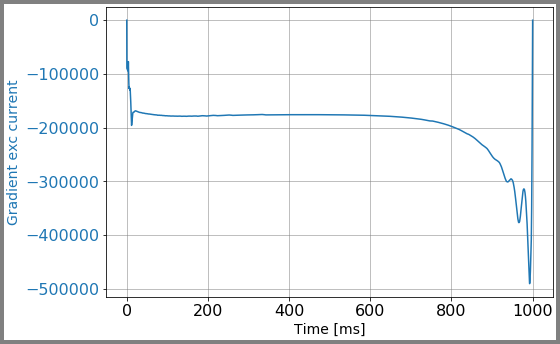

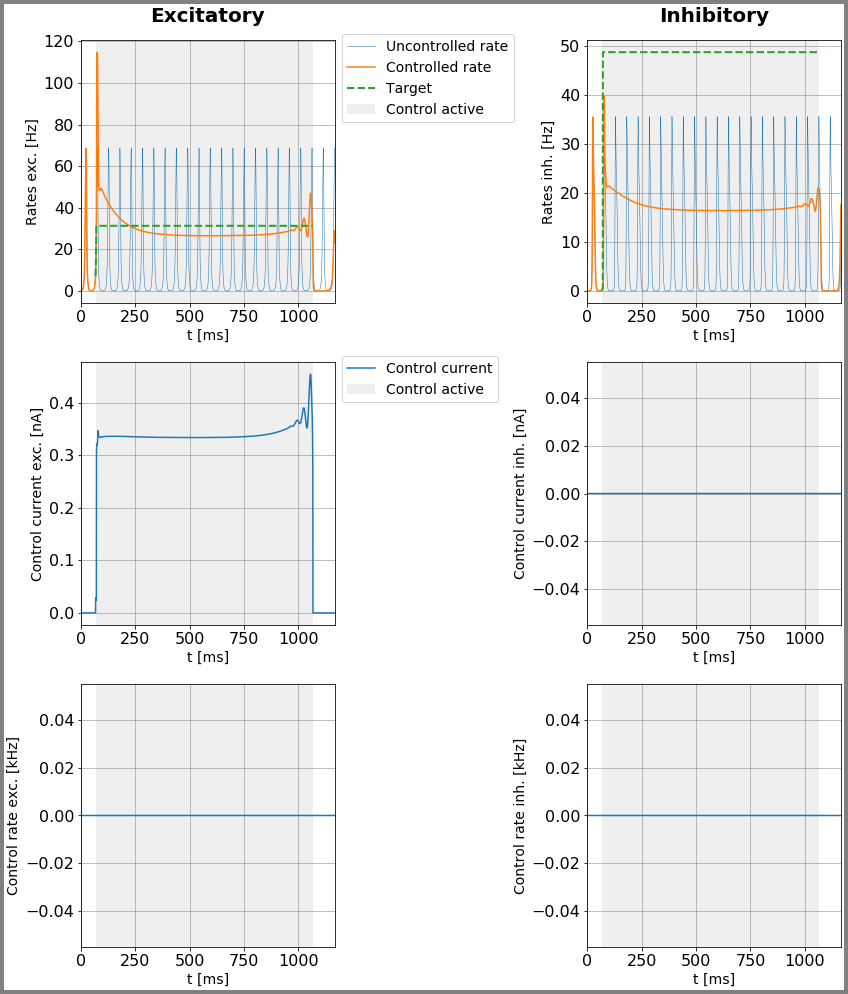

In [11]:
# C.0.a)

dur = 1000
dur_post = 100
n_dur = int(np.around(dur/aln.params.dt + 1.,1))
n_post = int(np.around(dur_post/aln.params.dt + 1.,1))

case_ind = 0
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

dur_pre, n_pre = setpredur(prec_vars)

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

setinit(initVars)
control0 = aln.getZeroControl()

control0[0,0,n_dt_maxDelay:] = 1.4
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

"""
RUN  0 , total integrated cost =  120304.23529451675
RUN  1 , total integrated cost =  120284.69388875752
RUN  2 , total integrated cost =  120284.68487878371
"""

set cost params
RUN  0 , total integrated cost =  179460.11446189208


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  179460.11446189208
Control only changes marginally.
RUN  1 , total integrated cost =  179460.11446189208
Improved over  1  iterations by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -57.49408332297601 -57.453865405607615
Problem in initial value trasfer:  Vmean_exc -56.671863733426875 -56.672441437614125


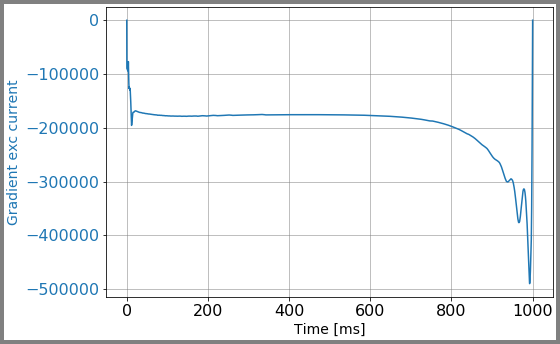

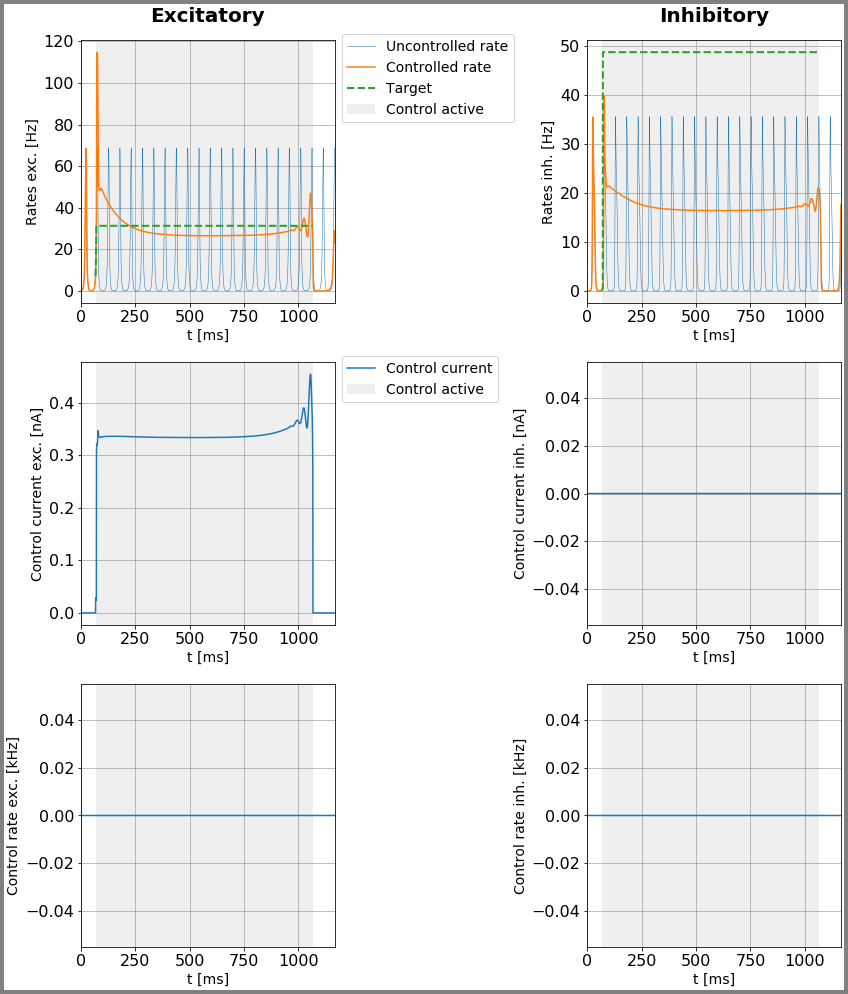

In [12]:

# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 100.0, 10.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0[0,0,n_dt_maxDelay:] = -5.
control1 = bestControla[:,:,n_pre-1:-n_post+1]
#control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True,
            crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )


## 2

set cost params
control input:  [2] , precision measure:  [0]
RUN  0 , total integrated cost =  316920.7224984266
RUN  1 , total integrated cost =  316659.5785760526
RUN  2 , total integrated cost =  316659.5785760525
RUN  3 , total integrated cost =  316659.57857605244


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  316659.57857605244
Control only changes marginally.
RUN  4 , total integrated cost =  316659.57857605244
Improved over  4  iterations by  0.0824003934849884  percent.
Problem in initial value trasfer:  sigmae_f 1.5645757287481894 1.5193679185738262
Problem in initial value trasfer:  Vmean_exc -57.49408332297601 -57.30587013512728
Problem in initial value trasfer:  tau_exc 7.3250855712119645 7.566741830787183
Problem in initial value trasfer:  sigmae_f 1.5244028691051015 1.5257060499413329
Problem in initial value trasfer:  Vmean_exc -60.2253524182084 -60.28120651255612
Problem in initial value trasfer:  tau_exc 15.001427259274864 14.984737801625895


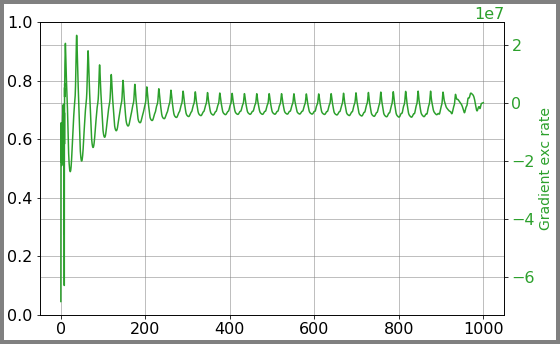

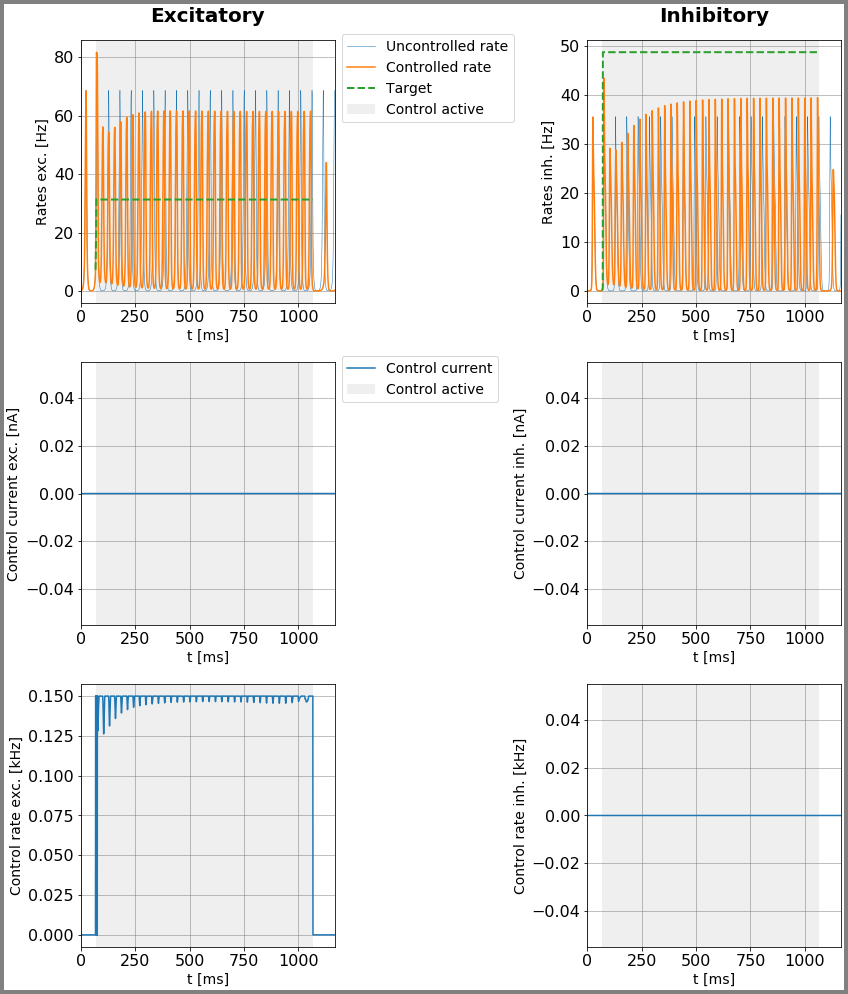

In [15]:
# A.0.a)

case_ind = 2
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

setinit(initVars)
control0 = aln.getZeroControl()
control0[:,2,:] = 0.15
control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

max_it = 30

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl,  t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

# 67940

set cost params
RUN  0 , total integrated cost =  377920.0011535748
RUN  1 , total integrated cost =  374850.5983666738
RUN  2 , total integrated cost =  374601.9156676173
RUN  3 , total integrated cost =  374601.915667617
RUN  4 , total integrated cost =  374601.9156676168


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  5 , total integrated cost =  374601.9156676168
Control only changes marginally.
RUN  5 , total integrated cost =  374601.9156676168
Improved over  5  iterations by  0.877986207617937  percent.
Problem in initial value trasfer:  sigmae_f 1.5645757287481894 1.5193679185738262
Problem in initial value trasfer:  Vmean_exc -57.49408332297601 -57.30587013512728
Problem in initial value trasfer:  tau_exc 7.3250855712119645 7.566741830787183
Problem in initial value trasfer:  sigmae_f 1.5239607965731208 1.5252977911415377
Problem in initial value trasfer:  Vmean_exc -60.28844036014729 -60.344083415915506
Problem in initial value trasfer:  tau_exc 15.108406188397943 15.091219758209645


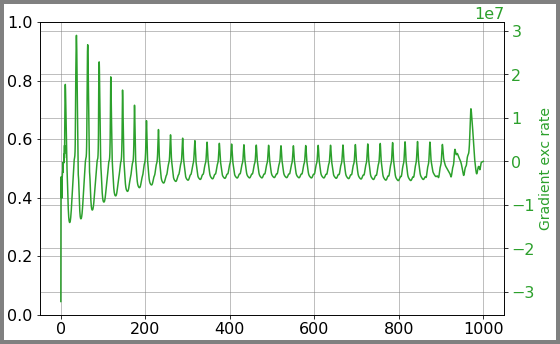

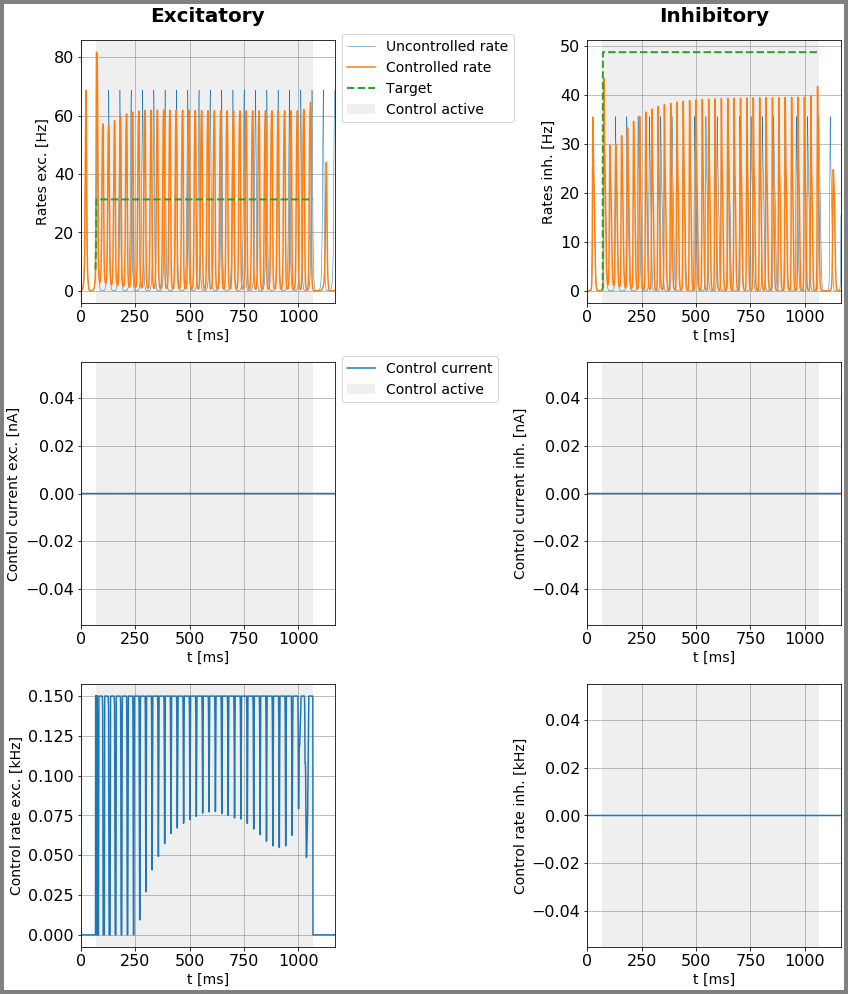

In [16]:

# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 5000.0, 1000.0)

aln.params.duration = dur

setinit(initVars)
ontrol0 = aln.getZeroControl()
control0[0,2,:] = 0.15
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

## 4

set cost params
control input:  [1] , precision measure:  [0]
RUN  0 , total integrated cost =  26274.994985620982
RUN  1 , total integrated cost =  24094.645007043808
RUN  2 , total integrated cost =  23995.386719414302
RUN  3 , total integrated cost =  23995.386719414193
RUN  4 , total integrated cost =  23995.38671941417
RUN  5 , total integrated cost =  23995.386719414153
RUN  6 , total integrated cost =  23995.386719414146


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  7 , total integrated cost =  23995.386719414146
Control only changes marginally.
RUN  7 , total integrated cost =  23995.386719414146
Improved over  7  iterations by  8.675960804005314  percent.
Problem in initial value trasfer:  Vmean_exc -57.49408332297601 -57.453865405607615
Problem in initial value trasfer:  Vmean_exc -57.08962594320718 -57.09343479085854


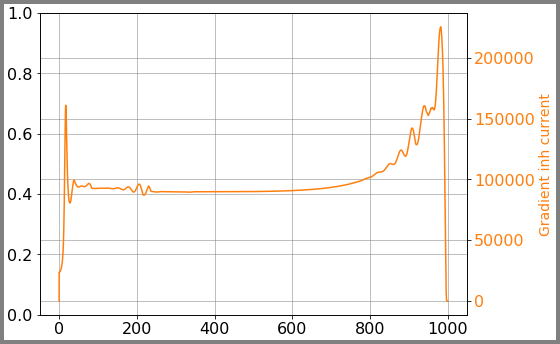

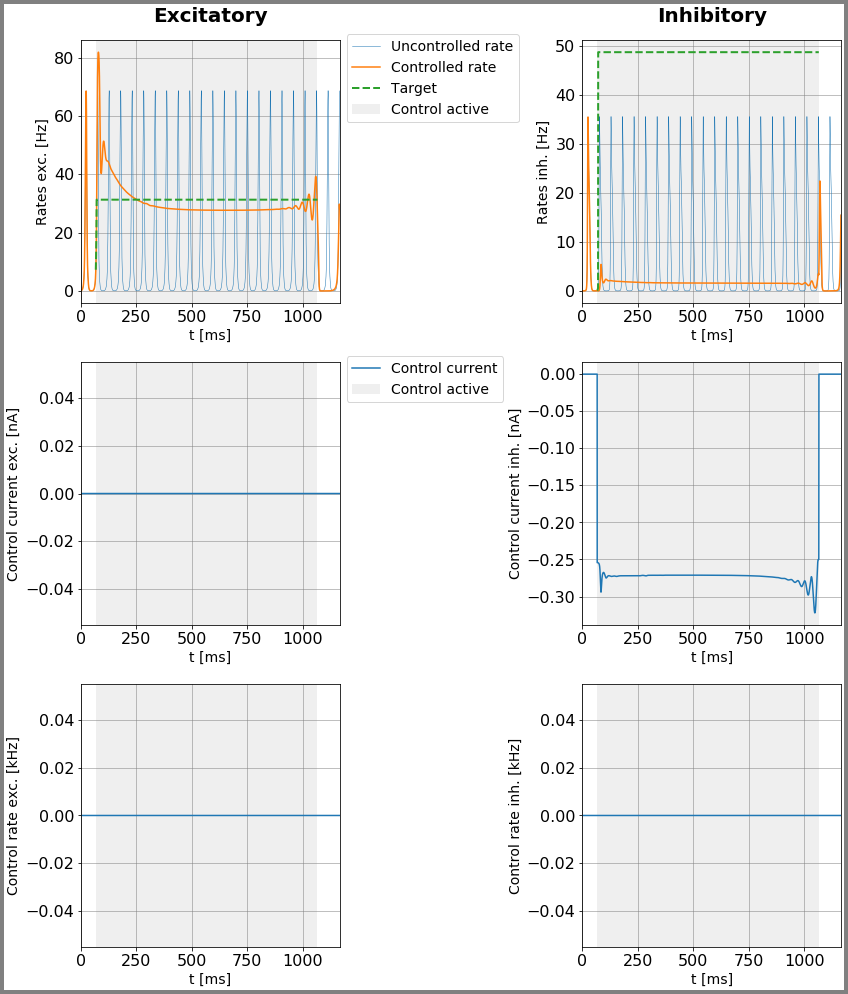

In [19]:
# A.4.a)

case_ind = 4
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,1,:] = -1.25
#control1 = bestControla[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.0)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  496078.7059901857


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  1 , total integrated cost =  496078.7059901857
Control only changes marginally.
RUN  1 , total integrated cost =  496078.7059901857
Improved over  1  iterations by  0.0  percent.
Problem in initial value trasfer:  Vmean_exc -57.49408332297601 -57.453865405607615
Problem in initial value trasfer:  Vmean_exc -57.08962594320718 -57.09343479085854


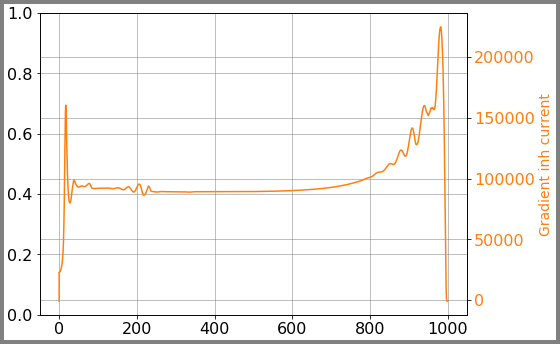

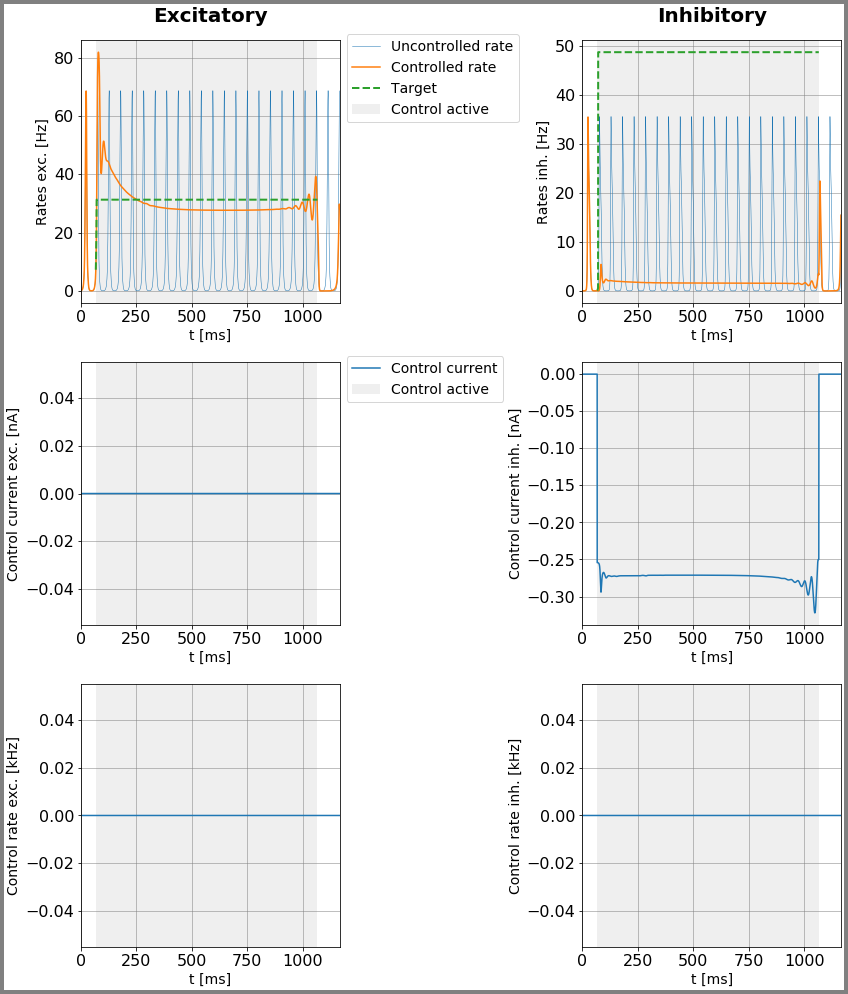

In [20]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 500.0, 100.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
#control0[0,1,:] = -1.
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control1, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

## 6

set cost params
control input:  [0, 1] , precision measure:  [0]
RUN  0 , total integrated cost =  27629.18260470764
RUN  1 , total integrated cost =  26263.656186273514
RUN  2 , total integrated cost =  26262.549731866227
RUN  3 , total integrated cost =  26262.549731866195
RUN  4 , total integrated cost =  26262.549731866184
RUN  5 , total integrated cost =  26262.549731866176
RUN  6 , total integrated cost =  26262.549731866173
RUN  7 , total integrated cost =  26262.549731866162
RUN  8 , total integrated cost =  26262.54973186615
RUN  9 , total integrated cost =  26262.54973186614
RUN  10 , total integrated cost =  26262.54973186613


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  11 , total integrated cost =  26262.54973186613
Control only changes marginally.
RUN  11 , total integrated cost =  26262.54973186613
Improved over  11  iterations by  4.946338414690032  percent.
Problem in initial value trasfer:  Vmean_exc -57.49408332297601 -57.453865405607615
Problem in initial value trasfer:  Vmean_exc -56.63191699236294 -56.63148360639394


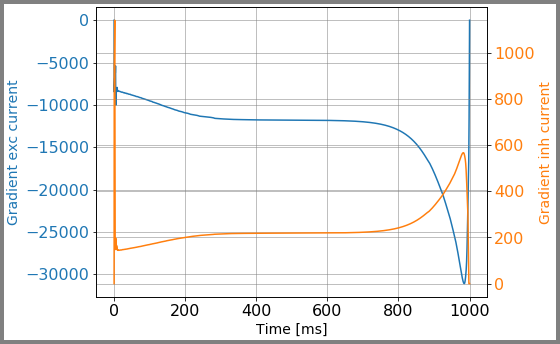

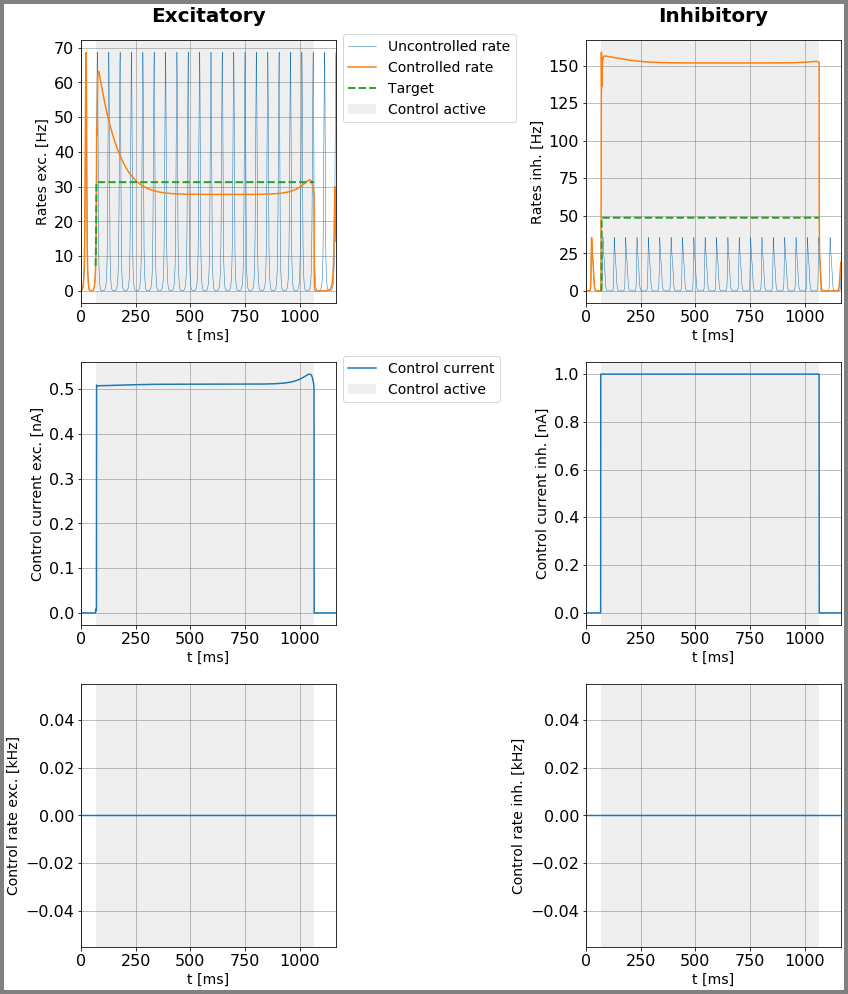

In [23]:
# A.6.a)
case_ind = 6
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,n_dt_maxDelay:] = 2.5
control0[0,1,:] = 5.
#control1 = bestControla[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

max_it = 30

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.0)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  213873.70286705747
RUN  1 , total integrated cost =  100734.50239469006
RUN  2 , total integrated cost =  99205.63081361812
RUN  3 , total integrated cost =  99195.86564195967
RUN  4 , total integrated cost =  99195.38717684922
RUN  5 , total integrated cost =  99195.30197137155
RUN  6 , total integrated cost =  99195.29887549447
RUN  7 , total integrated cost =  99195.29881139127
RUN  8 , total integrated cost =  99195.29881023522
RUN  9 , total integrated cost =  99195.29881005127
RUN  10 , total integrated cost =  99195.29881002654
RUN  11 , total integrated cost =  99195.29881002188
RUN  12 , total integrated cost =  99195.29881002149
RUN  13 , total integrated cost =  99195.29881002122
RUN  14 , total integrated cost =  99195.29881002117


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  15 , total integrated cost =  99195.29881002117
Control only changes marginally.
RUN  15 , total integrated cost =  99195.29881002117
Improved over  15  iterations by  53.619684196668004  percent.
Problem in initial value trasfer:  Vmean_exc -57.49408332297601 -57.453865405607615
Problem in initial value trasfer:  Vmean_exc -59.09942034081521 -58.99732410364937


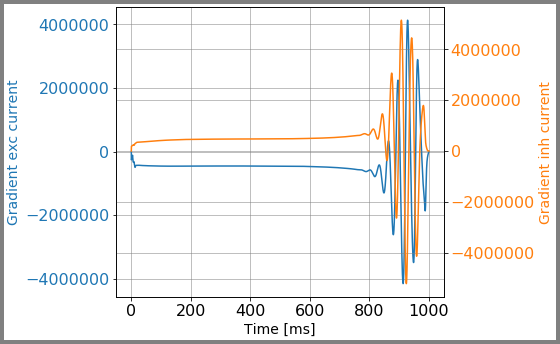

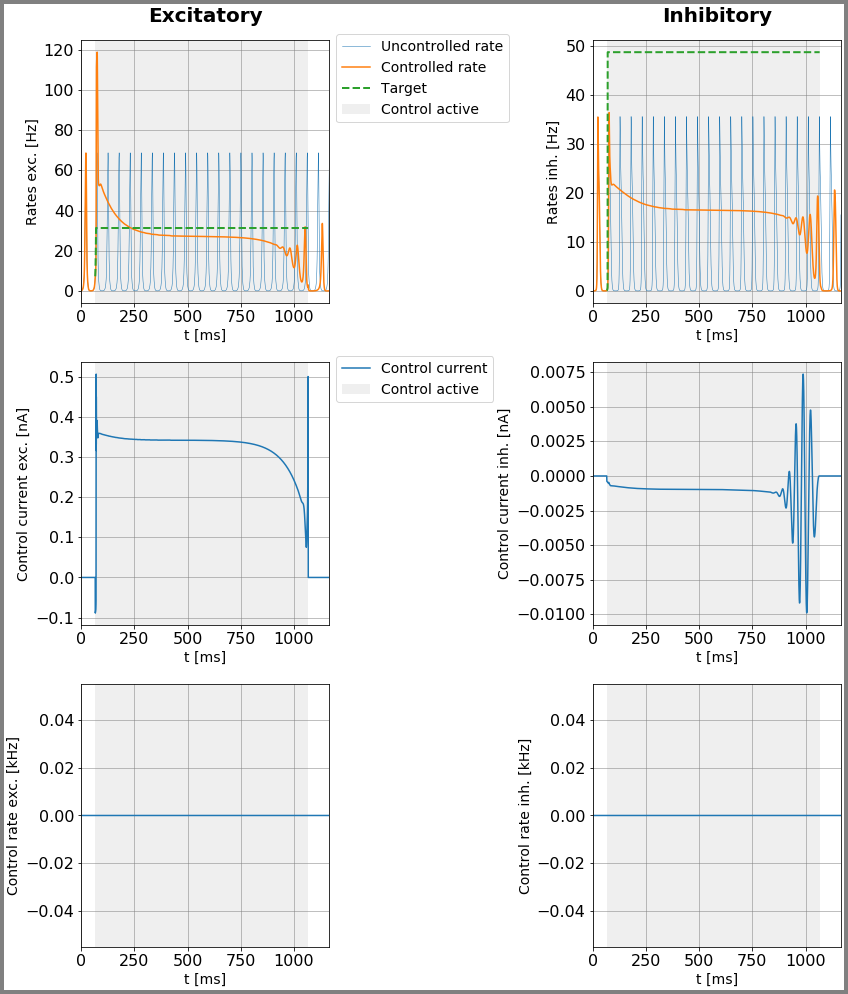

In [24]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,n_dt_maxDelay:] = 2.5
#control0[0,1,:] = 1.
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

#3813.6338429321895

## 8

set cost params
control input:  [0, 2] , precision measure:  [0]
RUN  0 , total integrated cost =  128940.92299997149
RUN  1 , total integrated cost =  54130.85993570335
RUN  2 , total integrated cost =  54130.85993570326


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  3 , total integrated cost =  54130.85993570326
Control only changes marginally.
RUN  3 , total integrated cost =  54130.85993570326
Improved over  3  iterations by  58.01886734150706  percent.
Problem in initial value trasfer:  Vmean_exc -57.49408332297601 -57.453865405607615
Problem in initial value trasfer:  Vmean_exc -57.15067029599666 -57.105010206641204


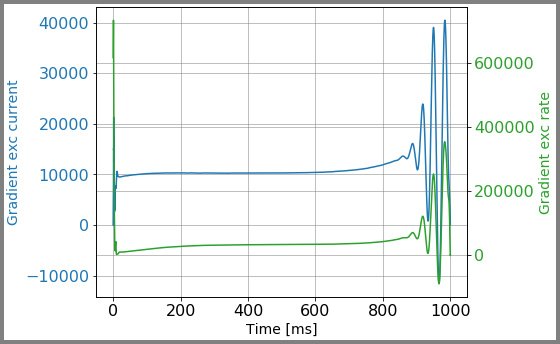

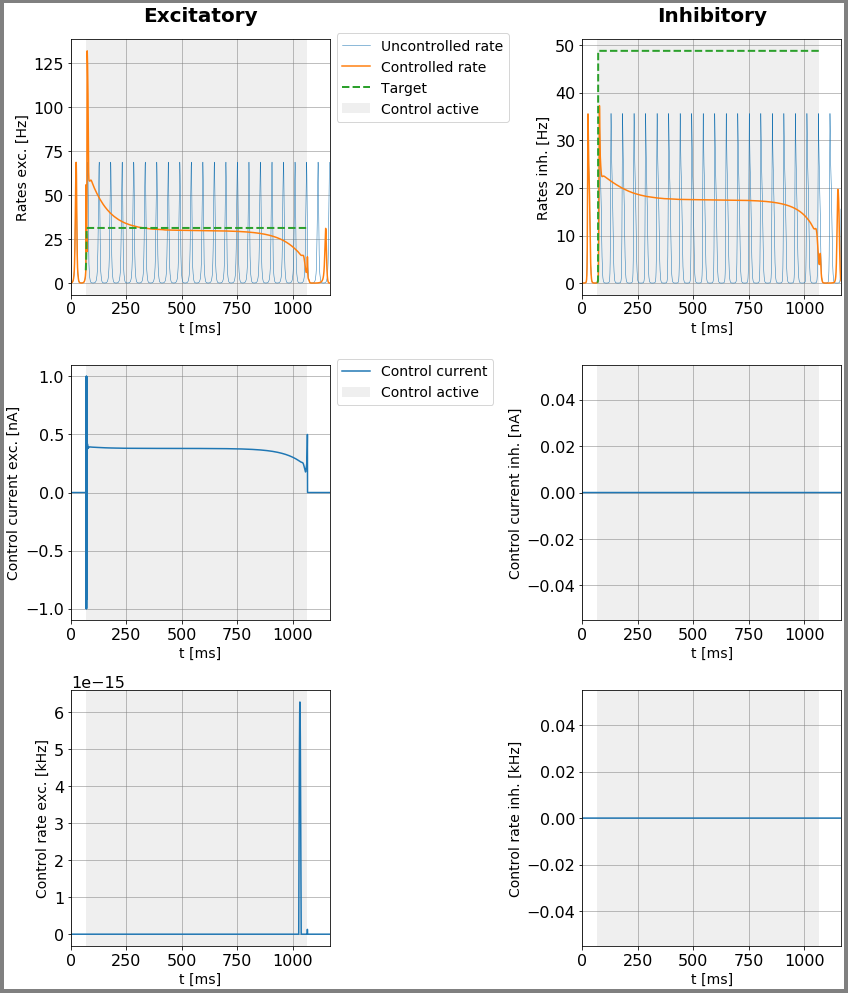

In [27]:
# A.8.a)
case_ind = 8
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,:] = 2.5
#control0[0,2,:] = 0.15
#control1 = bestControla[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  222937.4806827289
RUN  1 , total integrated cost =  100592.72491658582
RUN  2 , total integrated cost =  99249.52386675507
RUN  3 , total integrated cost =  99175.88485281242
RUN  4 , total integrated cost =  99168.82881691681
RUN  5 , total integrated cost =  99167.16592421776
RUN  6 , total integrated cost =  99166.68953446517
RUN  7 , total integrated cost =  99166.65045048782
RUN  8 , total integrated cost =  99166.65045048764
RUN  9 , total integrated cost =  99166.6504504875
RUN  10 , total integrated cost =  99166.65045048748


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  11 , total integrated cost =  99166.65045048748
Control only changes marginally.
RUN  11 , total integrated cost =  99166.65045048748
Improved over  11  iterations by  55.51817929098453  percent.
Problem in initial value trasfer:  sigmae_f 1.5645757287481894 1.5491223706809842
Problem in initial value trasfer:  Vmean_exc -57.49408332297601 -57.403276272928906
Problem in initial value trasfer:  tau_exc 7.3250855712119645 7.4076907824352904
Problem in initial value trasfer:  Vmean_exc -60.159988213049246 -60.0413270648554


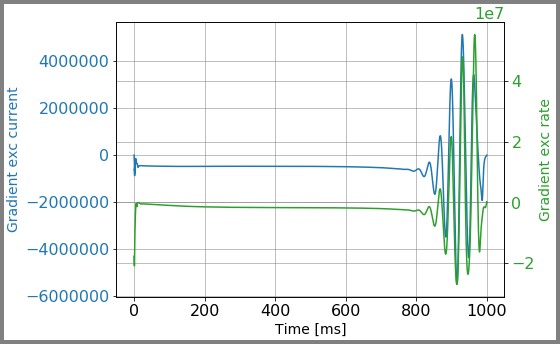

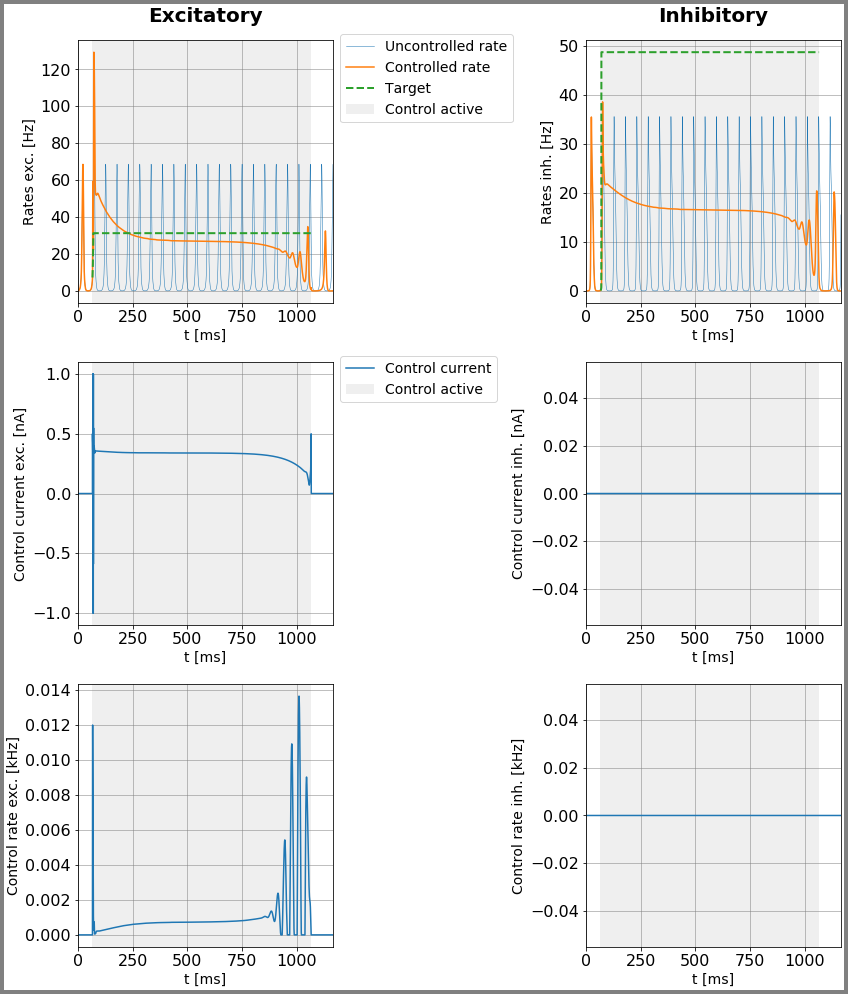

In [28]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,:] = 2.5
#control0[0,2,:] = 0.15
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True,
            crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

## 10

set cost params
control input:  [1, 2] , precision measure:  [0]
RUN  0 , total integrated cost =  30453.177778986304
RUN  1 , total integrated cost =  28956.360814931726
RUN  2 , total integrated cost =  20798.373703763347
RUN  3 , total integrated cost =  20243.13882012485
RUN  4 , total integrated cost =  20208.649565435906
RUN  5 , total integrated cost =  20170.617265911398
RUN  6 , total integrated cost =  20154.534162882705
RUN  7 , total integrated cost =  20153.90099729741
RUN  8 , total integrated cost =  20153.895138949232
RUN  9 , total integrated cost =  20153.883864446798
RUN  10 , total integrated cost =  20153.883257310863
RUN  11 , total integrated cost =  20153.873545294522
RUN  12 , total integrated cost =  20153.805660390957
RUN  13 , total integrated cost =  20153.80566039094
RUN  14 , total integrated cost =  20153.80566039092
RUN  15 , total integrated cost =  20153.805660390917


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  16 , total integrated cost =  20153.805660390917
Control only changes marginally.
RUN  16 , total integrated cost =  20153.805660390917
Improved over  16  iterations by  33.82035265200564  percent.
Problem in initial value trasfer:  sigmae_f 1.5645757287481894 1.5591732949209824
Problem in initial value trasfer:  Vmean_exc -57.49408332297601 -57.43617964174032
Problem in initial value trasfer:  tau_exc 7.3250855712119645 7.353964031510088
Problem in initial value trasfer:  sigmae_f 1.757675174284525 1.7577364676210923
Problem in initial value trasfer:  Vmean_exc -57.04133325677445 -57.04463620038097
Problem in initial value trasfer:  tau_exc 2.1339531776350564 2.1339501268029952


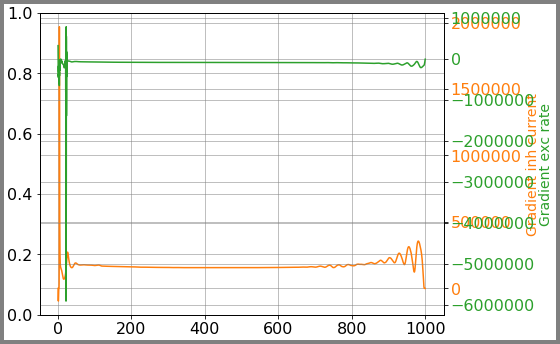

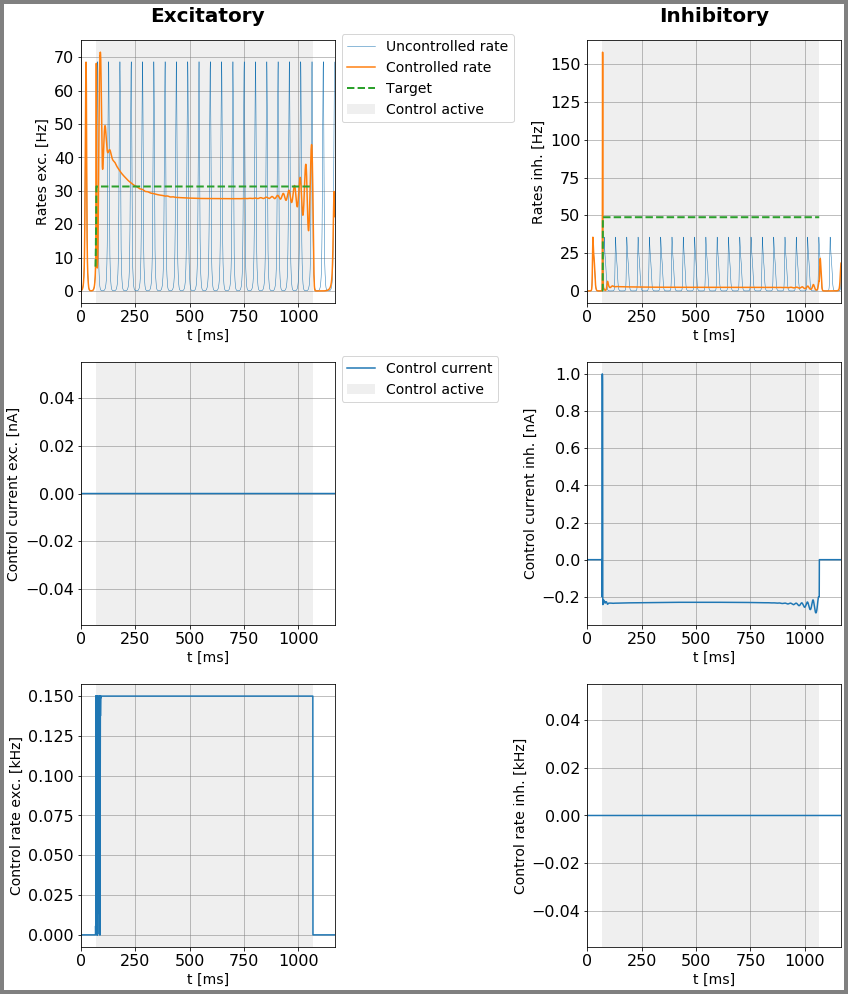

In [31]:
# A.10.a)
case_ind = 10
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,1,:] = -1.
control0[0,2,:] = 0.15
#control1 = bestControla[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

max_it = 30

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True)


plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  81946.97039255484
RUN  1 , total integrated cost =  80444.96221663704
RUN  2 , total integrated cost =  69274.16903689934
RUN  3 , total integrated cost =  69274.16903689933


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  4 , total integrated cost =  69274.16903689933
Control only changes marginally.
RUN  4 , total integrated cost =  69274.16903689933
Improved over  4  iterations by  15.464636819333691  percent.
Problem in initial value trasfer:  Vmean_exc -57.49408332297601 -57.453865405607615
Problem in initial value trasfer:  sigmae_f 1.7278383992737005 1.7280139836569135
Problem in initial value trasfer:  Vmean_exc -57.027158959540024 -57.02751017850996
Problem in initial value trasfer:  tau_exc 2.4213967611467515 2.4213665930368395


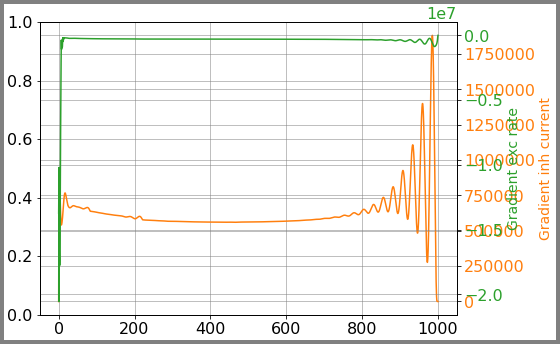

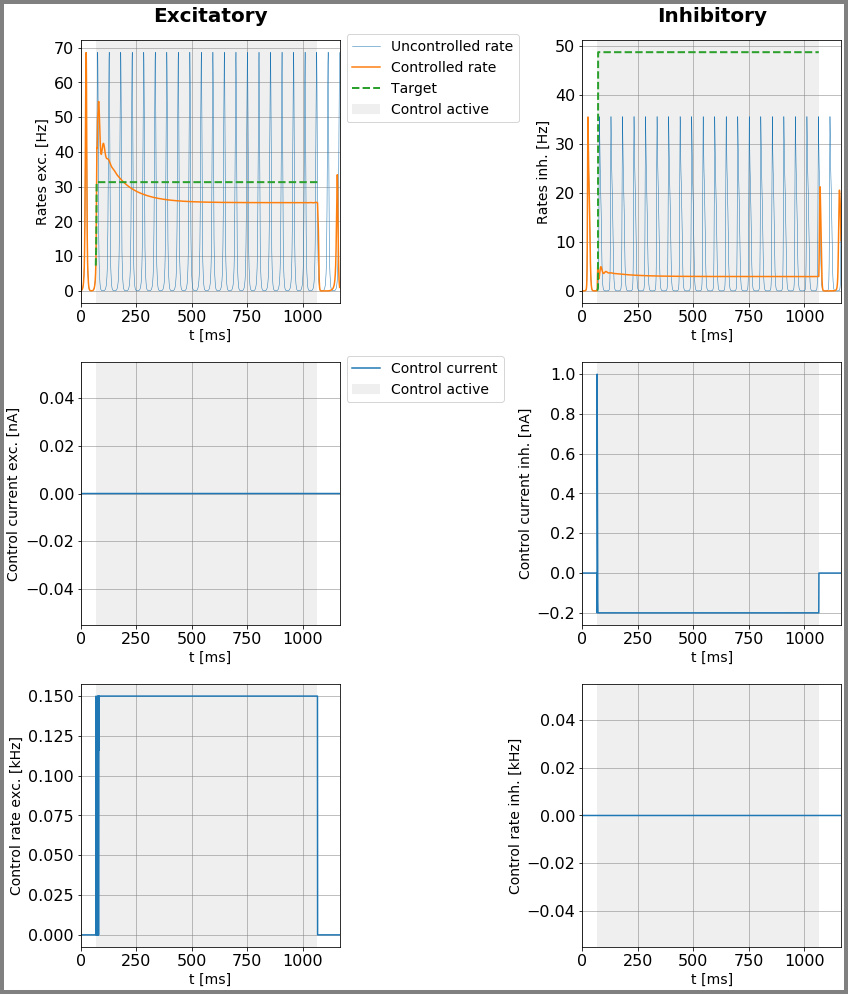

In [32]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 100.0, 10.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,1,:] = -1.
control0[0,2,:] = 0.15
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
            max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step,
            max_control_ = max_cntrl, min_control_ = min_cntrl,
            t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post,
            CGVar = cgv, control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True,
            crop_dir = 0.0)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

## 12

set cost params
control input:  [0, 1, 2] , precision measure:  [0]
RUN  0 , total integrated cost =  47562.44639338345
RUN  1 , total integrated cost =  30303.809465000653
RUN  2 , total integrated cost =  30230.07983153026
RUN  3 , total integrated cost =  30229.228279224382
RUN  4 , total integrated cost =  30229.19664881133
RUN  5 , total integrated cost =  30229.195987650633
RUN  6 , total integrated cost =  30229.19596251412
RUN  7 , total integrated cost =  30229.195962038713
RUN  8 , total integrated cost =  30229.195962035632
RUN  9 , total integrated cost =  30229.19596203562
RUN  10 , total integrated cost =  30229.195962035472
RUN  11 , total integrated cost =  30229.19596203543
RUN  12 , total integrated cost =  30229.195962035392
RUN  13 , total integrated cost =  30229.195962035385


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  14 , total integrated cost =  30229.195962035385
Control only changes marginally.
RUN  14 , total integrated cost =  30229.195962035385
Improved over  14  iterations by  36.44314316380358  percent.
Problem in initial value trasfer:  Vmean_exc -57.49408332297601 -57.453865405607615
Problem in initial value trasfer:  Vmean_exc -56.69221657295343 -56.69356541448849


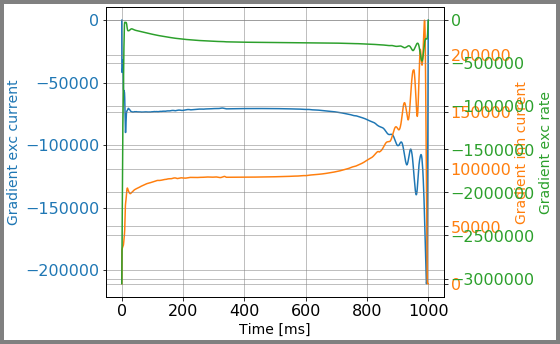

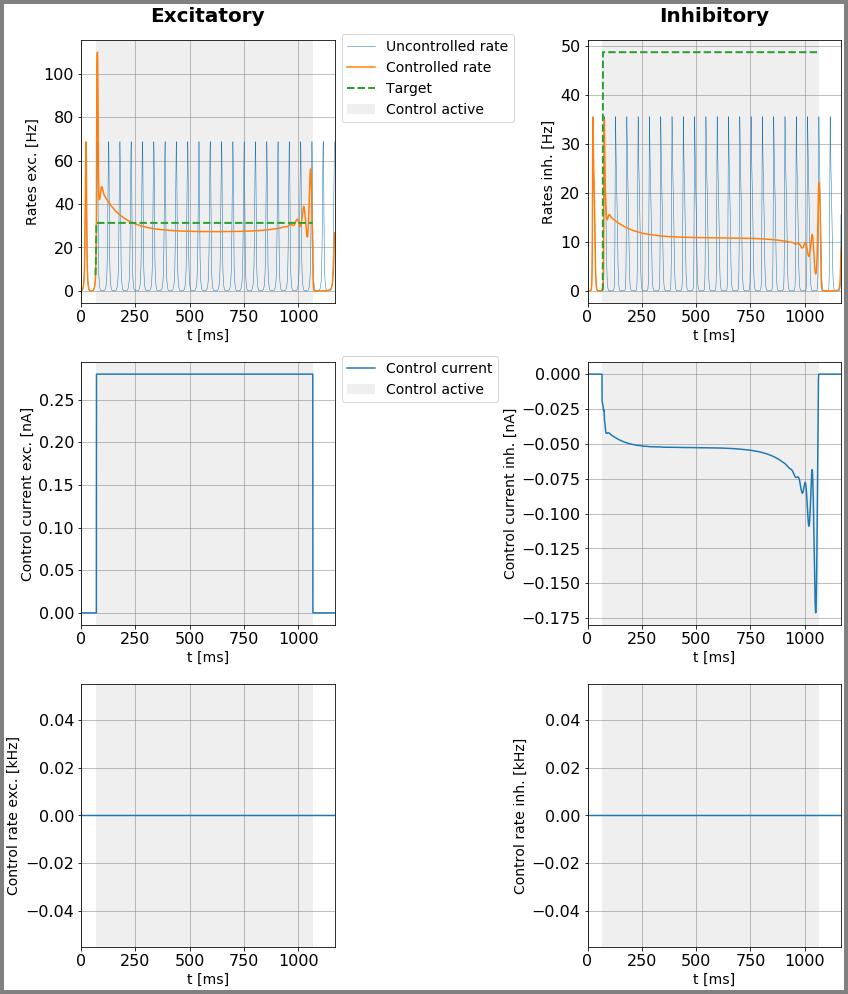

In [35]:
# A.12.a)
case_ind = 12
case = sheet + str(case_ind) + "a"
cost.setParams(1.0, 0.0, 0.0)
cntrl_vars = c_var[case_ind]
prec_vars = p_var[case_ind]

max_cntrl, min_cntrl = setmaxmincontrol(cntrl_vars)

dur_pre, n_pre = setpredur(prec_vars)

target = settarget(initVars, dur, dur_pre, n_pre)

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,n_dt_maxDelay:] = 1.4
#control0[0,1,:] = -1.
#control1 = bestControla[:,:,n_pre:-n_post]

# "HS", "FR", "PR", "HZ"
cgv = None

print("control input: ", cntrl_vars, ", precision measure: ", prec_vars)

bestControla, bestStatea, costa, runtimea, grada = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)

plotFunc.plot_gradient(grada, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControla, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )

set cost params
RUN  0 , total integrated cost =  76980.34281155594
RUN  1 , total integrated cost =  60797.99018931339
RUN  2 , total integrated cost =  60691.93235697301
RUN  3 , total integrated cost =  60689.89110287481
RUN  4 , total integrated cost =  60689.84884747789
RUN  5 , total integrated cost =  60689.848117385925
RUN  6 , total integrated cost =  60689.84811217529
RUN  7 , total integrated cost =  60689.84811187915
RUN  8 , total integrated cost =  60689.848111844476
RUN  9 , total integrated cost =  60689.848111837935
RUN  10 , total integrated cost =  60689.848111836895
RUN  11 , total integrated cost =  60689.84811183688
RUN  12 , total integrated cost =  60689.848111836865
RUN  13 , total integrated cost =  60689.84811183686
RUN  14 , total integrated cost =  60689.84811183685


ERROR:root:Problem in initial value trasfer
ERROR:root:Problem in initial value trasfer


RUN  15 , total integrated cost =  60689.84811183685
Control only changes marginally.
RUN  15 , total integrated cost =  60689.84811183685
Improved over  15  iterations by  21.161889002751536  percent.
Problem in initial value trasfer:  Vmean_exc -57.49408332297601 -57.453865405607615
Problem in initial value trasfer:  Vmean_exc -56.69189452201767 -56.69264114300791


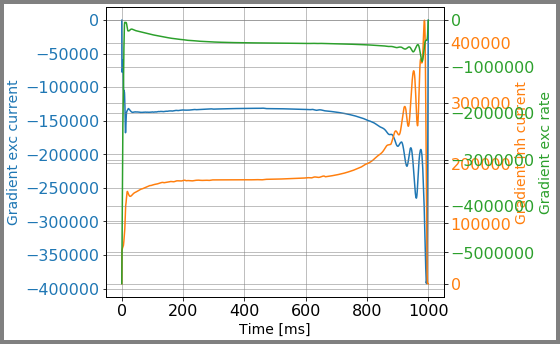

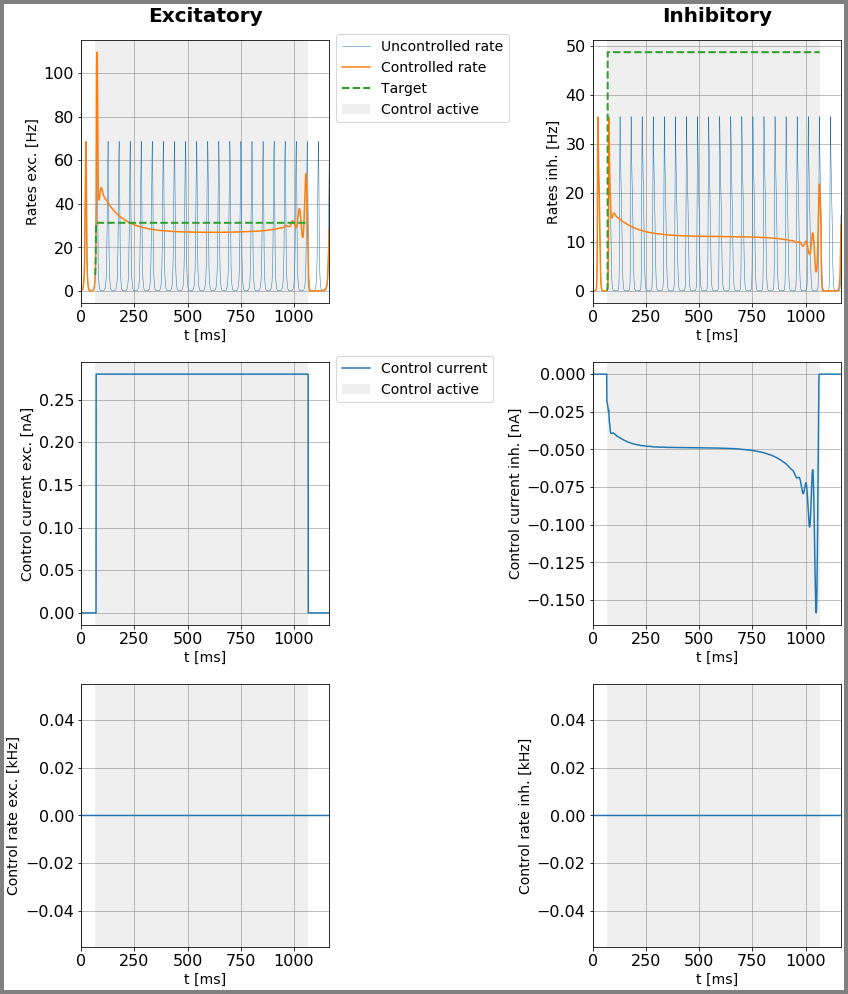

In [36]:
# A.0.b) high => low, exc current max 1nA, precision + energy + sparsity
case = sheet + str(case_ind) + "b"
cost.setParams(1.0, 30.0, 3.0)

aln.params.duration = dur

setinit(initVars)
control0 = aln.getZeroControl()
control0[0,0,n_dt_maxDelay:] = 1.4
control1 = bestControla[:,:,n_pre-1:-n_post+1]
control2 = bestControlb[:,:,n_pre-1:-n_post+1]

# "HS", "FR", "PR", "HZ"
cgv = None

bestControlb, bestStateb, costb, runtimeb, gradb = aln.A1(control0, target, c_scheme, u_mat, u_scheme,
    max_iteration_ = max_it, tolerance_ = tol, startStep_ = start_step, max_control_ = max_cntrl,
    min_control_ = min_cntrl, t_sim_ = dur, t_sim_pre_ = dur_pre, t_sim_post_ = dur_post, CGVar = cgv,
    control_variables_ = cntrl_vars, prec_variables_ = prec_vars, separate_comp = True, crop_dir = 0.)

plotFunc.plot_gradient(gradb, dur, aln.params.dt, path, plot_vars = cntrl_vars)
plotFunc.plot_control(aln, bestControlb, dur, dur_pre, dur_post, initVars, target,
                      path, filename_ = case )